# Análisis Exploratorio y Detección de Perfiles (EDA)

Este notebook realiza un análisis profundo de los patrones de atención, correlacionando las diferentes tareas (Stroop, Flanker, SART) e identificando perfiles mediante técnicas de Machine Learning no supervisado (Clustering).

In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.0-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.1-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     ------------- ------------------------- 41.0/116.4 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 116.4/116.4 kB 2.3 MB/s eta 0:00:00
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.4 MB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style('whitegrid')

## 1. Carga de Datos Procesados

In [5]:
data_path = '../data/processed/final_dataset_with_features.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path, index_col=0)
    print(f"Datos cargados: {df.shape}")
    display(df.head())
else:
    print("¡ALERTA! Debes ejecutar src/make_dataset.py primero para generar el dataset.")

Datos cargados: (466, 21)


,flanker_rt,flanker_accuracy,flanker_error_rate,stroop_rt,stroop_accuracy,stroop_error_rate,sart_rt,sart_accuracy,sart_error_rate,stroop_rt_std,...,stroop_rt_median,stroop_congruent_rt,stroop_incongruent_rt,stroop_interference,flanker_rt_std,flanker_rt_mean_recalc,flanker_rt_median,flanker_congruent_rt,flanker_incongruent_rt,flanker_interference
subjectid,,,,,,,,,,,,,,,,,,,,,
1,378.220690,0.972414,0.027586,747.280576,0.949640,0.050360,558.618090,0.984925,0.015075,304.974512,...,633.0,675.130435,821.703125,146.572690,69.497241,379.617021,361.0,366.840580,391.861111,25.020531
2,705.220690,0.896552,0.103448,947.697479,0.974790,0.025210,351.964912,0.900585,0.099415,594.003006,...,980.0,1027.492754,1170.435484,142.942730,242.970597,666.353846,586.5,648.432836,685.412698,36.979863
3,456.075862,0.965517,0.034483,732.086957,0.992754,0.007246,352.404255,0.925532,0.074468,330.843644,...,654.5,701.710145,784.478261,82.768116,101.173003,458.542857,433.5,448.791667,468.867647,20.075980
4,376.041379,0.986207,0.013793,714.117647,0.955882,0.044118,284.262712,0.906780,0.093220,360.713509,...,638.5,790.565217,696.079365,-94.485852,125.166006,377.566434,348.0,382.547945,372.371429,-10.176517
5,504.675862,0.993103,0.006897,661.058394,0.934307,0.065693,317.842857,0.938095,0.061905,371.663052,...,593.0,695.015152,702.261538,7.246387,155.145574,506.180556,473.0,468.486111,543.875000,75.388889


## 2. Correlaciones entre Tareas
¿Están correlacionados los efectos de interferencia? (e.g. Stroop Interference vs Flanker Interference)

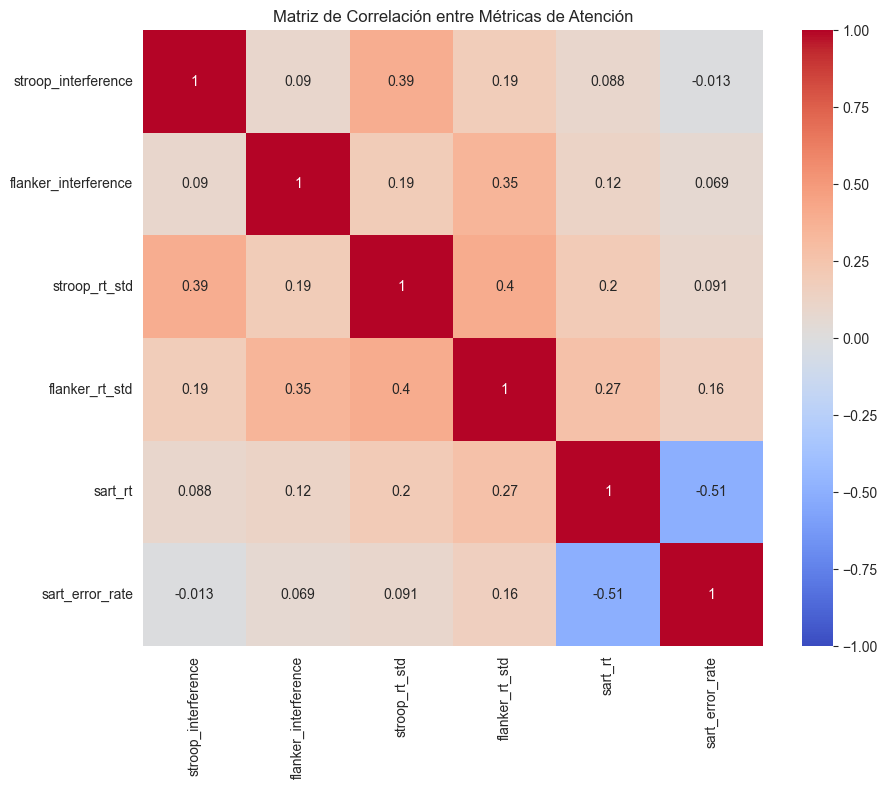

In [6]:
cols_interest = [
    'stroop_interference', 'flanker_interference', 
    'stroop_rt_std', 'flanker_rt_std',
    'sart_rt', 'sart_error_rate'
]
# Filtrar solo columnas que existen
cols_present = [c for c in cols_interest if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_present].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Métricas de Atención')
plt.show()

## 3. Identificación de Perfiles (Clustering)
Utilizaremos K-Means para agrupar sujetos con perfiles atencionales similares basándonos en sus métricas.

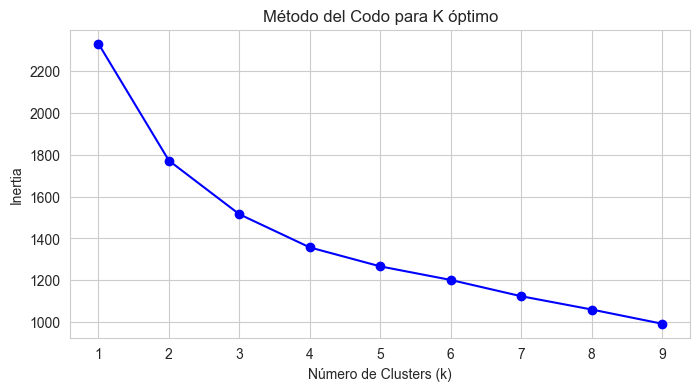

In [7]:
# Selección de features para clustering
# Usamos las métricas de rendimiento y variabilidad
features_clus = ['stroop_interference', 'flanker_interference', 'sart_error_rate', 'stroop_rt_mean_recalc', 'flanker_rt_mean_recalc']
features_clus = [c for c in features_clus if c in df.columns]

X = df[features_clus].dropna()

# Estandarización (CRÍTICO para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determinar número óptimo de clusters (Elbow Method)
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inertia')
plt.title('Método del Codo para K óptimo')
plt.show()

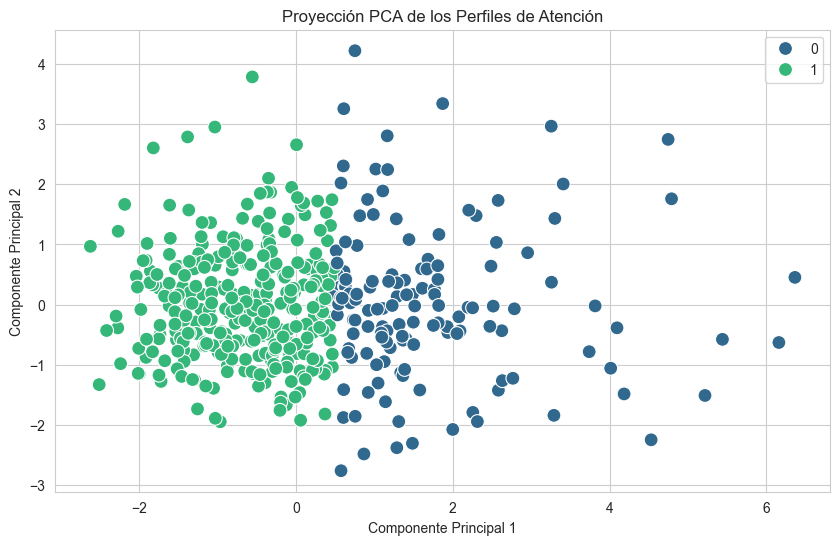

In [9]:
# Aplicar K-Means con k=3 (por defecto, ajustar según gráfico anterior)
k_opt = 2
kmeans = KMeans(n_clusters=k_opt, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X['Cluster'] = clusters
df.loc[X.index, 'Cluster'] = clusters

# Visualización PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='viridis', s=100)
plt.title('Proyección PCA de los Perfiles de Atención')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

## 4. Caracterización de los Perfiles
¿Qué significa cada cluster? Analizamos los promedios de cada feature por cluster.

,stroop_interference,flanker_interference,sart_error_rate,stroop_rt_mean_recalc,flanker_rt_mean_recalc
Cluster,,,,,
0.0,159.526331,58.361937,0.064658,993.159435,514.241607
1.0,78.886996,38.149222,0.057416,729.548663,420.729224


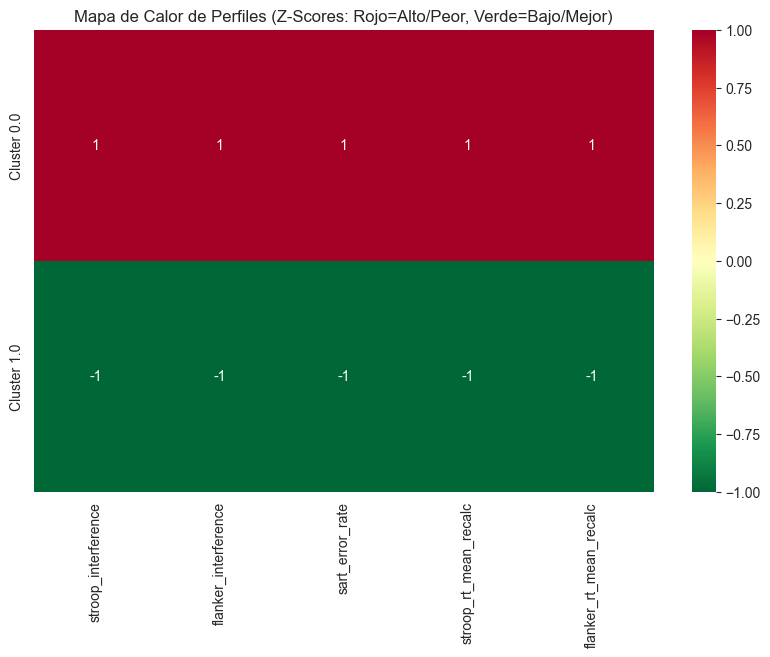

In [10]:
profile_summary = df.groupby('Cluster')[features_clus].mean()
display(profile_summary)

# Heatmap de perfiles (z-scores para comparar)
plt.figure(figsize=(10, 6))
sns.heatmap(scaler.fit_transform(profile_summary), annot=True, cmap='RdYlGn_r', yticklabels=[f'Cluster {i}' for i in profile_summary.index], xticklabels=features_clus)
plt.title('Mapa de Calor de Perfiles (Z-Scores: Rojo=Alto/Peor, Verde=Bajo/Mejor)')
plt.show()